Found 48 Excel files in C:\Users\44mes\OneDrive - University of Kansas\Sprinig 2026\Block 2\1st Paper\Algorithims for block1-after rejection\n per k sensitivity


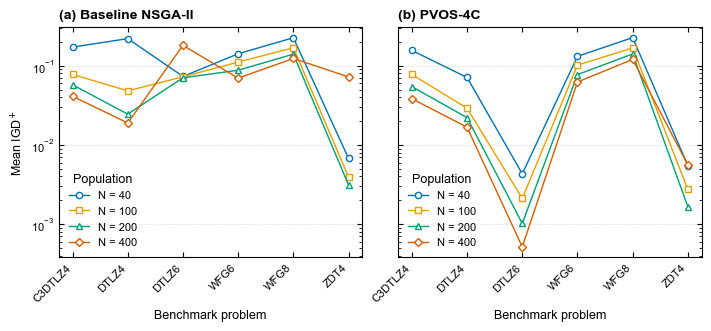

Figure  -> C:\Users\44mes\OneDrive - University of Kansas\Sprinig 2026\Block 2\1st Paper\Algorithims for block1-after rejection\n per k sensitivity\fig_igd_vs_problem_nsga2_pvos4c.pdf
Figure  -> C:\Users\44mes\OneDrive - University of Kansas\Sprinig 2026\Block 2\1st Paper\Algorithims for block1-after rejection\n per k sensitivity\fig_igd_vs_problem_nsga2_pvos4c.png
Summary -> C:\Users\44mes\OneDrive - University of Kansas\Sprinig 2026\Block 2\1st Paper\Algorithims for block1-after rejection\n per k sensitivity\mean_igd_plus_summary.csv


In [1]:
"""
plot_igd_vs_problem.py
----------------------
Scans the current folder for Excel result files and produces ONE publication-
quality figure for Applied Soft Computing (Elsevier) submission:

    Left panel  : Baseline NSGA-II  — mean IGD+ vs. benchmark, one line per pop size
    Right panel : PVOS-4C            — mean IGD+ vs. benchmark, one line per pop size

Formatting follows ACS / Elsevier figure guidelines:
    * double-column width (7.0 in), ~3.2 in tall
    * Arial, 9 pt base / 8 pt ticks / 10 pt panel titles
    * log-scale y-axis (IGD+ spans several orders of magnitude)
    * colorblind-safe Okabe-Ito palette, 1.0 pt lines, open markers
    * exports PDF (vector, editable text) + PNG (600 dpi) + CSV summary

Usage: place this file next to the Excel files and run `python plot_igd_vs_problem.py`.
Requires: pandas, numpy, matplotlib, openpyxl.
"""

import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ #
# ACS / Elsevier plotting style
# ------------------------------------------------------------------ #
mpl.rcParams.update({
    "font.family":       "Arial",
    "font.size":          9,
    "axes.titlesize":    10,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
    "xtick.top":         True,
    "ytick.right":       True,
    "lines.linewidth":   1.0,
    "lines.markersize":  4.5,
    "legend.frameon":    False,
    "savefig.dpi":       600,
    "savefig.bbox":      "tight",
    "pdf.fonttype":      42,   # editable text in PDF (TrueType)
    "ps.fonttype":       42,
})

# Okabe-Ito colorblind-safe palette
POP_COLORS  = {50: "#0072B2", 100: "#E69F00", 200: "#009E73", 400: "#D55E00"}
POP_MARKERS = {50: "o",        100: "s",        200: "^",        400: "D"}

# ------------------------------------------------------------------ #
# Helpers
# ------------------------------------------------------------------ #
def normalize_name(s: str) -> str:
    s = s.lower().replace("-", " ").replace("_", " ")
    return re.sub(r"\s+", " ", s).strip()

def extract_problem(filename: str) -> str:
    return normalize_name(Path(filename).stem).split(" ")[0].upper()

def parse_generations(filename: str) -> int:
    m = re.search(r"(\d+)\s*gen\b", normalize_name(Path(filename).stem))
    return int(m.group(1)) if m else -1

def parse_pop_size(norm: str) -> int | None:
    for n in (50, 100, 200, 400):
        if re.search(rf"\b{n}\s*pop\b", norm):
            return n
    return None

def classify_method(filename: str):
    """Return (algorithm, pop_size) or None if the file is neither."""
    norm = normalize_name(Path(filename).stem)
    pop  = parse_pop_size(norm)
    if pop is None:
        return None

    has_sbx, has_spx = "sbx" in norm, "spx" in norm
    has_blx, has_ux  = "blx" in norm, "ux"  in norm

    # PVOS-4C: all four crossovers present
    if has_sbx and has_spx and has_blx and has_ux:
        return ("PVOS-4C", pop)

    # Baseline NSGA-II: sbx + "cross" + "poly", with "1"-style marker, no other ops
    if (has_sbx and "cross" in norm and "poly" in norm
            and (re.search(r"\b1\b", norm) or re.search(r"\b1\s*sbx\b", norm))
            and not (has_spx or has_blx or has_ux)):
        return ("NSGA-II", pop)

    return None

def find_col(df: pd.DataFrame, keys):
    """Pick the best-matching column by earliest key rank (tiebreak: shorter name)."""
    best = (len(keys), float("inf"), None)
    for c in df.columns:
        n = normalize_name(str(c))
        for rank, k in enumerate(keys):
            if k in n:
                if (rank, len(n)) < (best[0], best[1]):
                    best = (rank, len(n), c)
                break
    return best[2]

def igd_seed_minima(df: pd.DataFrame):
    if df is None or df.empty:
        return None
    igd_col  = find_col(df, ["igd+", "igd plus", "igdplus", "igd"])
    seed_col = find_col(df, ["seed"])
    if igd_col is None or seed_col is None:
        return None
    v   = pd.to_numeric(df[igd_col], errors="coerce")
    tmp = df[[seed_col]].assign(VAL=v).dropna(subset=["VAL"])
    return None if tmp.empty else tmp.groupby(seed_col)["VAL"].min()

def aggregate_file(path: str):
    """Min-per-seed across all sheets, then mean across seeds."""
    try:
        xls = pd.ExcelFile(path)
    except Exception as e:
        print(f"[WARN] cannot open {path}: {e}")
        return (None, 0)

    parts = []
    for sh in xls.sheet_names:
        try:
            s = igd_seed_minima(xls.parse(sheet_name=sh))
            if s is not None and not s.empty:
                parts.append(s)
        except Exception as e:
            print(f"[WARN] sheet '{sh}' in {Path(path).name}: {e}")

    if not parts:
        return (None, 0)
    merged = pd.concat(parts).groupby(level=0).min()
    return (float(merged.mean()), int(merged.index.nunique()))

# ------------------------------------------------------------------ #
# Scan + aggregate
# ------------------------------------------------------------------ #
cwd  = Path(".").resolve()
xlsx = [str(p) for ext in ("*.xlsx", "*.xls")
        for p in cwd.glob(ext) if not p.name.startswith("~$")]
print(f"Found {len(xlsx)} Excel files in {cwd}")

groups = defaultdict(list)
for f in xlsx:
    info = classify_method(f)
    if info is None:
        continue
    algo, pop = info
    groups[(extract_problem(f), algo, pop)].append((parse_generations(f), f))

# for each (problem, algo, pop) keep the file with most generations
selected = {k: max(v, key=lambda t: t[0])[1] for k, v in groups.items()}

rows = []
for (problem, algo, pop), f in selected.items():
    mean_igd, n_seeds = aggregate_file(f)
    rows.append({"problem":       problem,
                 "algorithm":     algo,
                 "pop":           pop,
                 "mean_igd_plus": mean_igd,
                 "seeds":         n_seeds,
                 "file":          Path(f).name})

results_df = pd.DataFrame(rows)

out_dir = cwd   # save next to the notebook / Excel files
results_df.to_csv(out_dir / "mean_igd_plus_summary.csv", index=False)

if results_df.empty:
    raise SystemExit("No matching Excel files found — nothing to plot.")

# ------------------------------------------------------------------ #
# Publication figure: 1 x 2 subplots (NSGA-II | PVOS-4C)
# ------------------------------------------------------------------ #
problems = sorted(results_df["problem"].unique())
x        = np.arange(len(problems))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2),
                         sharey=True, constrained_layout=True)

panels = [("NSGA-II", "(a) Baseline NSGA-II", axes[0]),
          ("PVOS-4C", "(b) PVOS-4C",          axes[1])]

for algo, title, ax in panels:
    sub = results_df[results_df["algorithm"] == algo]
    for pop in sorted(sub["pop"].unique()):
        y = [sub.loc[(sub["problem"] == p) & (sub["pop"] == pop),
                     "mean_igd_plus"].mean()
             for p in problems]
        ax.plot(x, y,
                color           = POP_COLORS.get(pop, "black"),
                marker          = POP_MARKERS.get(pop, "o"),
                markerfacecolor = "white",
                markeredgewidth = 1.0,
                label           = f"N = {50 if pop == 50 else pop}")

    ax.set_yscale("log")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(problems, rotation=45, ha="right")
    ax.set_xlabel("Benchmark problem")
    ax.grid(True, which="major", axis="y",
            linestyle=":", linewidth=0.5, alpha=0.7)
    ax.legend(title="Population", loc="best", handlelength=1.8)

axes[0].set_ylabel(r"Mean IGD$^{+}$")

pdf_path = out_dir / "fig_igd_vs_problem_nsga2_pvos4c.pdf"
png_path = out_dir / "fig_igd_vs_problem_nsga2_pvos4c.png"
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=600)
plt.show()

print(f"Figure  -> {pdf_path}")
print(f"Figure  -> {png_path}")
print(f"Summary -> {out_dir / 'mean_igd_plus_summary.csv'}")